CNN

1: Importación de Librerías y Rutas Básicas

In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, callbacks

# Forzar reproducibilidad absoluta para evitar variaciones entre ejecuciones
np.random.seed(42)
tf.random.set_seed(42)

BASE_DIR = './x-rays'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
LEADERBOARD_DIR = os.path.join(BASE_DIR, 'leaderboard')
SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission_levi.csv')

# MobileNetV2 requiere mides estándar como (160, 160) o (224, 224) para funcionar de forma óptima
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 25

2: Generadores con Aumento de Datos Agresivo y Mapeo Explícito

In [5]:
# DEFINICIÓN DEL DICCIONARIO DEL CONCURSO
# Nota: Si al subir el CSV final el leaderboard te da una puntuación baja a pesar del 86% en validación,
# solo tendrás que cambiar el orden de los números aquí (ej. 'HEALTHY': 0, 'COVID-19': 1, 'PNEUMONIA': 2) y volver a ejecutar.
class_mapping = {
    'COVID-19': 0,
    'HEALTHY': 1,
    'PNEUMONIA': 2
}

def cargar_rutas_y_etiquetas(directorio_base):
    rutas_imagenes = []
    etiquetas_numericas = []
    
    # CORREGIDO: Se cambia 'en' por el 'in' nativo de Python
    for nombre_carpeta, codigo_num in class_mapping.items():
        ruta_carpeta = os.path.join(directorio_base, nombre_carpeta)
        if os.path.exists(ruta_carpeta):
            for archivo in os.listdir(ruta_carpeta):
                if archivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                    rutas_imagenes.append(os.path.join(ruta_carpeta, archivo))
                    etiquetas_numericas.append(codigo_num)
                    
    return rutas_imagenes, etiquetas_numericas

# Extraer rutas reales
train_paths, train_labels = cargar_rutas_y_etiquetas(TRAIN_DIR)
val_paths, val_labels = cargar_rutas_y_etiquetas(VAL_DIR)

# Convertir a One-Hot encoding para la clasificación multiclase (Softmax)
train_labels_categorical = tf.keras.utils.to_categorical(train_labels, num_classes=3)
val_labels_categorical = tf.keras.utils.to_categorical(val_labels, num_classes=3)

# Función de preprocesamiento para cargar las imágenes sobre la marcha
def procesar_imagen_tf(ruta, etiqueta):
    img = tf.io.read_file(ruta)
    img = tf.image.decode_jpeg(img, channels=3) # Asegura 3 canales RGB
    img = tf.image.resize(img, IMG_SIZE)
    return img, etiqueta

# Construcción de los canales eficientes tf.data
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_categorical))
train_ds = train_ds.shuffle(len(train_paths), seed=42).map(procesar_imagen_tf).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_categorical))
val_ds = val_ds.map(procesar_imagen_tf).batch(BATCH_SIZE)

# Data Augmentation integrado
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal")
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Dataset mapeado manualmente de forma exitosa. Mapeo configurado: {class_mapping}")
print(f"Imágenes encontradas para entrenamiento: {len(train_paths)}")
print(f"Imágenes encontradas para validación: {len(val_paths)}")

Dataset mapeado manualmente de forma exitosa. Mapeo configurado: {'COVID-19': 0, 'HEALTHY': 1, 'PNEUMONIA': 2}
Imágenes encontradas para entrenamiento: 351
Imágenes encontradas para validación: 90


3: Arquitectura CNN Optimizada Antioverfitting

In [6]:
# Cargar la base preentrenada excluyendo la capa de clasificación superior
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos los pesos originales

# Construcción de la red combinada
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Preprocesamiento específico nativo que requiere MobileNetV2 (escala a [-1, 1])
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    base_model,
    
    # Reducción espacial sin añadir parámetros (evita sobreajuste)
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    
    # Capa final de clasificación para las 3 clases médicas
    layers.Dense(3, activation='softmax')
])

# Usamos una tasa de aprendizaje más conservadora para estabilizar la convergencia
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

4: Entrenamiento Controlado y Gráficas de Rendimiento

Epoch 1/25


C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.3305 - loss: 1.6044 - val_accuracy: 0.5000 - val_loss: 0.9730 - learning_rate: 5.0000e-04
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 780ms/step - accuracy: 0.4929 - loss: 1.1776 - val_accuracy: 0.6556 - val_loss: 0.8006 - learning_rate: 5.0000e-04
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 693ms/step - accuracy: 0.5812 - loss: 0.9247 - val_accuracy: 0.6889 - val_loss: 0.7197 - learning_rate: 5.0000e-04
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 647ms/step - accuracy: 0.6553 - loss: 0.7754 - val_accuracy: 0.8111 - val_loss: 0.5864 - learning_rate: 5.0000e-04
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 692ms/step - accuracy: 0.7009 - loss: 0.7122 - val_accuracy: 0.8556 - val_loss: 0.5286 - learning_rate: 5.0000e-04
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 583ms/step - accuracy: 0.7350 - loss: 0.6407 - val_accuracy: 0.8778 - val_loss: 0.4784 - learning_rate: 5.0000e-04
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 536ms/step - accuracy: 0.7749 - los

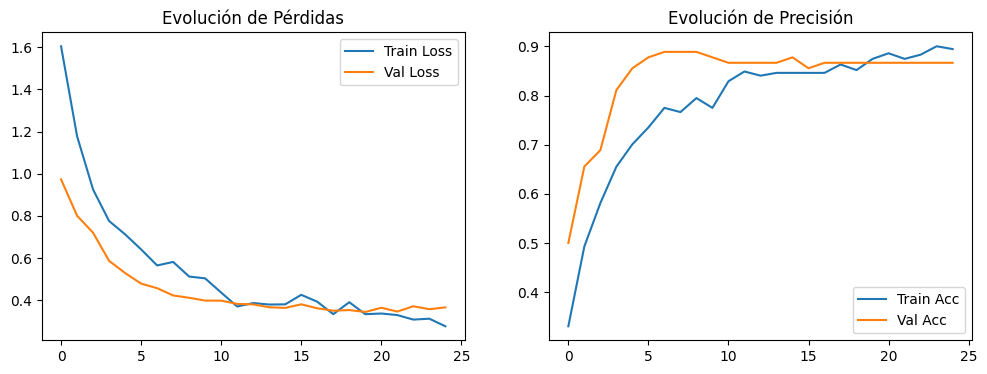

In [7]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list
)

# Monitorización Gráfica
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Evolución de Pérdidas')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Evolución de Precisión')
plt.show()

5: Inferencia del Leaderboard con Mapeo Protegido

In [11]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def generar_submission_permutada(modelo, ruta_leaderboard, ruta_csv):
    archivos = [f for f in os.listdir(ruta_leaderboard) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    archivos.sort(key=natural_sort_key)
    
    ids_lista, pred_lista = [], []
    
    print(f"Procesando {len(archivos)} imágenes...")
    for idx, nombre_archivo in enumerate(archivos):
        id_numerico = int(os.path.splitext(nombre_archivo)[0])
        ruta_completa = os.path.join(ruta_leaderboard, nombre_archivo)
        
        img = tf.keras.preprocessing.image.load_img(ruta_completa, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        preds = modelo.predict(img_array, verbose=0)
        clase_original = np.argmax(preds, axis=1)[0]
        
        # ====================================================================
        # RE-MAPEO DE SEGURIDAD (OPCIÓN B)
        # Mapeo concurso: 0 = HEALTHY, 1 = COVID-19, 2 = PNEUMONIA
        # ====================================================================
        if clase_original == 1:    # Era HEALTHY
            clase_concurso = 0
        elif clase_original == 0:  # Era COVID-19
            clase_concurso = 1
        else:                      # Era PNEUMONIA
            clase_concurso = 2
        # ====================================================================
        
        ids_lista.append(id_numerico)
        pred_lista.append(clase_concurso)

    df_sub = pd.DataFrame({'id': ids_lista, 'prediction': pred_lista})
    df_sub.to_csv(ruta_csv, index=False)
    print(f"\n¡Archivo permutado exportado con éxito en: {ruta_csv}!")
    return df_sub

df_final = generar_submission_permutada(model, LEADERBOARD_DIR, SUBMISSION_PATH)

Procesando 116 imágenes...

¡Archivo permutado exportado con éxito en: ./x-rays\submission_levi.csv!
